<!--
---
PURPOSE: Extract units and spike times; produce neural QC plots.
REQUIRES:
  - outputs/reports/session_inventory.parquet
PRODUCES:
  - outputs/neural/session_{id}_units.parquet
  - outputs/neural/session_{id}_spike_times.npz
WHAT_NEXT: notebooks/03_Behavior_and_Task_Alignment.ipynb
---
-->

# 02 Neural Data: Spikes and Events

**Purpose**
Extract units and spike times; produce neural QC plots.

**Requires**
- `outputs/reports/session_inventory.parquet`

**Produces**
- `outputs/neural/session_{id}_units.parquet`
- `outputs/neural/session_{id}_spike_times.npz`

**What to run next**
- `notebooks/03_Behavior_and_Task_Alignment.ipynb`

We load spike times, export tables, and generate QC plots.


## Environment Setup
We add the repo `src/` to the Python path so notebooks can import shared modules.

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
# Works whether JupyterLab is launched from repo root or from notebooks/
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
SRC  = ROOT / "src"

# put repo + src on sys.path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


#print("ROOT:", ROOT)
#print("SRC :", SRC, "| exists:", SRC.exists())
#print("sys.path[0:3]:", sys.path[:3])

## Prerequisite Check
We parse the notebook header and validate required artifacts before running downstream steps.

In [5]:
from pathlib import Path
from reports import parse_notebook_header, validate_prerequisites

nb_path = ROOT / "notebooks" / "02_Neural_Data_Spikes_and_Events.ipynb"
header  = parse_notebook_header(nb_path)
missing = validate_prerequisites(header.get("REQUIRES", []))

if missing:
    print("Missing prerequisites:")
    for item in missing:
        print(" -", item)
else:
    print("All prerequisites satisfied.")

All prerequisites satisfied.


## Step 1: Select sessions
Pick one or more session IDs to extract spikes. ID('s) should be in brackets. 

In [6]:
from io_sessions import load_sessions_csv, get_session_bundle

sessions = load_sessions_csv()
SESSION_IDS = [1055240613] # [1055240613]
SESSION_IDS

[1055240613]

## Step 2: Extract units and spikes
Spike times are exported to NPZ; units go to Parquet with metadata.

/opt/anaconda3/envs/vbn-analysis/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


1055240613 (734, 25)


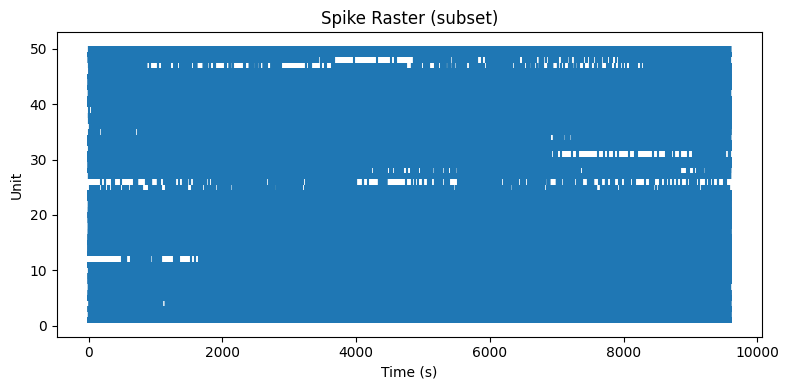

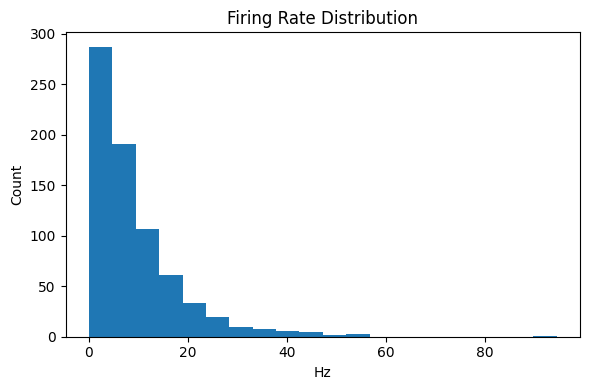

In [7]:
from viz import plot_raster, plot_firing_rate_summary

for session_id in SESSION_IDS:
    bundle = get_session_bundle(session_id, sessions)
    units, spikes = bundle.load_spikes()
    print(session_id, None if units is None else units.shape)
    plot_raster(spikes or {});
    plot_firing_rate_summary(spikes or {});